[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.





## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.


#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

//JF I will be making a case for the prosecution

In [14]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = [c for c in df.select_dtypes(include='category').columns if c != 'class']

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      6842
           1       0.72      0.61      0.66      2203

    accuracy                           0.85      9045
   macro avg       0.80      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045



// at first, the classifier had 100% precision/recall/and accuracy with no class 1 values, so I had to figure out why. When I discovered the error, I fixed the code and reran to find values in both class 0 and 1.

In [13]:
df['class'].dtype
df['class'].unique()
label_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'class']

// This shows us the class got label encoded into 0/1 to represent values before the line that checks for the original text

In [16]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")
model_adult.predict_proba(jane_df)


Prediction for Jane Dow (Loan Eligibility): Denied


array([[0.69666667, 0.30333333]])

// Here it is showing Jane is denied and all the possible factors being considered are age, workclass, education, marital status, occupation, relationship, race, sex, hours per week, native country, capital gain, capital loss and education num

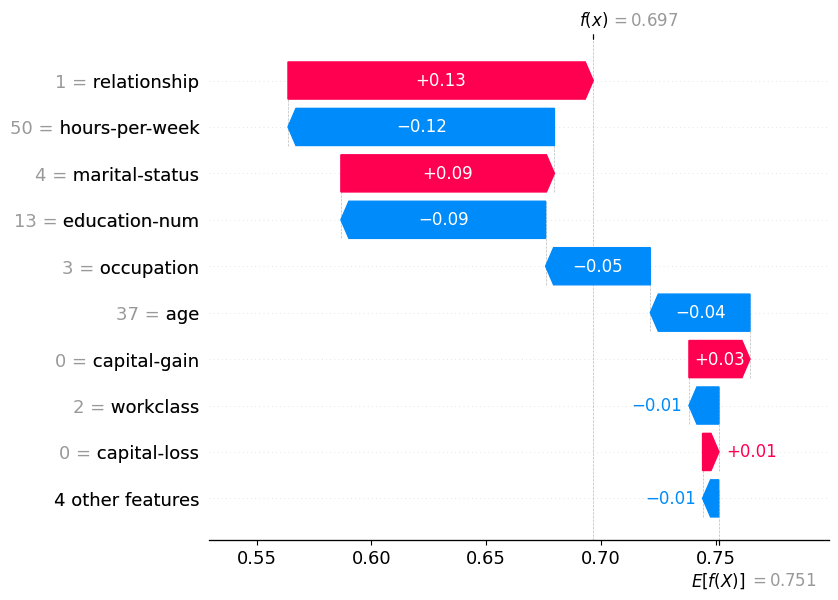

In [17]:
!pip install -q shap

import shap
explainer = shap.TreeExplainer(model_adult)
shap_values = explainer(jane_df)

predicted_class = 0  # Denied
shap.plots.waterfall(shap_values[0, :, predicted_class])

// Evaluating SHAP, we see the probability of the model denying all applicatiions is .75. While Jane doe is still below that at .70 looking at the graph of what pushed her closer to that denial is overwhelmingly features protected by the Equal Credit Opportunity Act, mainly relationship and marital status. While things that push her away are her occupation, hours per week and education.

In [18]:
!pip install -q lime

import lime.lime_tabular

categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                     'relationship', 'race', 'sex', 'native-country']
cat_idx = [X_train.columns.get_loc(c) for c in categorical_cols]

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=list(X_train.columns),
    class_names=['<=50K', '>50K'],
    categorical_features=cat_idx,
    discretize_continuous=True,
    random_state=42
)

lime_exp = explainer_lime.explain_instance(jane_df.values[0], model_adult.predict_proba, num_features=10)
for feature, weight in lime_exp.as_list():
    print(f"{feature:35s} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
capital-gain <= 0.00                -0.5955
capital-loss <= 0.00                -0.0999
hours-per-week > 45.00              +0.0941
marital-status=4                    -0.0713
10.00 < education-num <= 13.00      +0.0620
occupation=3                        +0.0604
relationship=1                      -0.0495
sex=0                               -0.0171
education=9                         +0.0064
race=4                              -0.0044


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


//LIME validates that marital status and relationship push towards denial. LIME also shows sex pushes towards denial, another Equal Credit Opportunity violation. While it also indicates a capital gain 0 pushes towards denial, nearly all the applicants in the dataset have 0.

In [20]:
protected_and_proxies = ['sex', 'race', 'marital-status', 'relationship', 'age', 'native-country']

X_train_fair = X_train.drop(columns=protected_and_proxies)
X_test_fair = X_test.drop(columns=protected_and_proxies)
jane_df_fair = jane_df.drop(columns=protected_and_proxies)

model_fair = RandomForestClassifier(random_state=42)
model_fair.fit(X_train_fair, y_train)

print(classification_report(y_test, model_fair.predict(X_test_fair)))

pred_fair = model_fair.predict(jane_df_fair)
proba_fair = model_fair.predict_proba(jane_df_fair)
print("Prediction for Jane Dow WITHOUT protected/proxy features:", "Approved" if pred_fair[0]==1 else "Denied")
print("Probability [<=50K, >50K]:", proba_fair)

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      6842
           1       0.71      0.45      0.55      2203

    accuracy                           0.82      9045
   macro avg       0.77      0.70      0.72      9045
weighted avg       0.81      0.82      0.81      9045

Prediction for Jane Dow WITHOUT protected/proxy features: Approved
Probability [<=50K, >50K]: [[0.33447231 0.66552769]]


// I wanted to check to see how removing the Equal Credit Opportunity act protects effected the model. We see that the models overall accuracy decreases but only slightly, from .85 to .82. With this experiment, Jane Doe is approved; which contributes to the prosecution's position that the original model unfairly weighed factors that has legal protections.